In [1]:
from latent_dubins_ca_wm_pil import LatentDubinContinuousAction, get_args, state_to_image_pil_hq
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class DubinEnv():
    def __init__(self, start_state, goal_state):
        self.start_state = start_state
        self.curr_state = start_state
        self.goal_state = goal_state
        self.args = get_args()
        self.v = self.args.speed
        self.dt = self.args.dt

    def forward(self, action):
        # Apply the action to the current state
        state_obs, img_obs, state_gt, dones, acs = ([] for _ in range(5))
        pstate = self.curr_state.copy()
        pstate[0] += self.v * np.cos(self.curr_state[2]) * self.dt
        pstate[1] += self.v * np.sin(self.curr_state[2]) * self.dt
        pstate[2] += action * self.dt  # Update the heading angle
        img = state_to_image_pil_hq(pstate, self.args)

        state_obs.append(pstate[2]) # get to observe theta
        state_gt.append(pstate) # gt state
        dones.append(1)
        acs.append(action)
        img_obs.append(img)

        demo = {}
        demo['obs'] = {'image': img_obs, 'state': state_obs, 'priv_state': state_gt}
        demo['actions'] = acs
        demo['dones'] = dones
        return demo, pstate
    
    def goal_ref(self):
        # Calculate the direction towards the goal
        dx = self.goal_state[0] - self.curr_state[0]
        dy = self.goal_state[1] - self.curr_state[1]
        angle_to_goal = np.arctan2(dy, dx)
        ref_theta = angle_to_goal
        delta_theta = ref_theta - self.curr_state[2]
        # Normalize the angle to be within [-pi, pi] using modulo operation
        delta_theta = (delta_theta + np.pi) % (2 * np.pi) - np.pi
        ref_theta_dot = (delta_theta) / self.dt

        return ref_theta, np.clip(ref_theta_dot, -self.args.turnRate, self.args.turnRate)


/home/clown2/Desktop/Work/Research/wm_cbf


## CBF on Latent Dubins

Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 27002886 variables.
Closest action index: 62, Value: 0.5443509817123413, Goal Action: -1.25
Step 1: Pstate: [-0.95  1.   -0.05], Goal: -0.79, Action: -0.9399999976158142, Dist: 2.23, Safe Value: 0.550000011920929
Closest action index: 86, Value: 0.5479643940925598, Goal Action: -1.25
Step 2: Pstate: [-0.9   1.   -0.09], Goal: -0.8, Action: -0.8199999928474426, Dist: 2.19, Safe Value: 0.5799999833106995
Closest action index: 116, Value: 0.5659454464912415, Goal Action: -1.25
Step 3: Pstate: [-0.85  0.99 -0.12], Goal: -0.82, Action: -0.6700000166893005, Dist: 2.15, Safe Value: 0.5899999737739563
Closest action index: 126, Value: 0.583322286605835, Goal Action: -1.25
Step 4: Pstate: [-0.8   0.99 -0.15], Goal: -0.83, Action: -0.6200000047683716, Dist: 2.12, Safe Value: 0.6000000238418579
Closest act

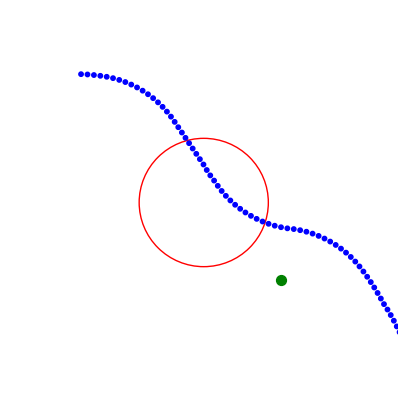

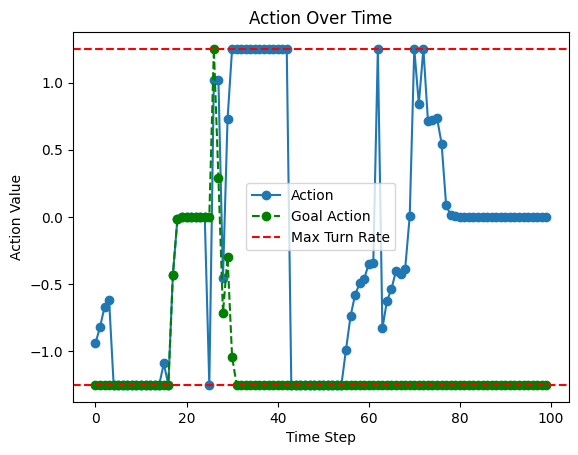

In [17]:
dubin_env = DubinEnv(start_state=np.array([-1.0, 1.0, 0.0]),
                     goal_state=0.6*np.array([1, -1, 0.0]))

brt = LatentDubinContinuousAction()

priv_states = []
actions = []
goal_actions = []
current_safe = []

epsilon = 0.2
gamma = 0.9
simlen = 100
u_min = -dubin_env.args.turnRate
u_max = dubin_env.args.turnRate
u_samples = 500
u_delta = (u_max - u_min) / u_samples
u_range = np.arange(u_min, u_max + u_delta, u_delta)  # action range for Dubins car
u_range = torch.tensor(u_range, dtype=torch.float32, device=brt.args.device).unsqueeze(-1)  # Convert to tensor

# first step
demo, priv_state = dubin_env.forward(0)
safe_value, safe_action = brt.obs_to_brt(demo)

to_np = lambda x: x.cpu().detach().numpy()

for i in range(simlen):
    # get goal reference direction and action
    goal_dir, goal_act = dubin_env.goal_ref()
    # single step look-ahead
    curr_safe = 1 

    # import pdb; pdb.set_trace()  # Debugging point to inspect values

    feat = brt.data_to_feat(demo)
    # Vz = brt.evaluate_V(to_np(feat))[0]
    Vz = safe_value
    Lz = brt.margin_fn(feat)[0][0][0]
    Vz = np.min([Vz, to_np(Lz)])
    Qzs = brt.evaluate_Q(to_np(feat), u_range)

    cbf_cond = Qzs > gamma * Vz
    Qzs_valid_idx = np.where(cbf_cond)[0]

    if Qzs_valid_idx.size == 0:
        print("No valid actions found, using goal action.")
        action = goal_act
    else:
        # Find the action that maximizes the Q-value while satisfying the CBF condition
        Qzs_valid = Qzs[Qzs_valid_idx]
        # Find the action that minimizes the distance to the goal action
        closest_action = np.argmin(np.abs(Qzs_valid - goal_act))
        print(f"Closest action index: {closest_action}, Value: {Qzs_valid[closest_action]}, Goal Action: {goal_act}")
        action = u_range[closest_action][0].detach().cpu().numpy()

    # import pdb; pdb.set_trace()  # Debugging point to inspect values

    demo, priv_state = dubin_env.forward(action)
    safe_value, _ = brt.obs_to_brt(demo) # actual safe value after taking the action
    dubin_env.curr_state = priv_state  # Update the current state in the environment

    priv_states.append(priv_state)
    actions.append(action)
    goal_actions.append(goal_act)
    current_safe.append(curr_safe)

    distance = np.linalg.norm(dubin_env.goal_state[:2] - dubin_env.curr_state[:2])
    print(f"Step {i+1}: Pstate: {np.round(priv_state,2)}, "
          f"Goal: {np.round(goal_dir,2)}, "
          f"Action: {np.around(action,2)}, "
          f"Dist: {np.round(distance,2)}, "
          f"Safe Value: {np.round(safe_value, 2)}")
    
    if distance < 0.05:
        print("Reached the goal!")
        break


# plot the trajectory history and circle obstacle 
fig,ax = plt.subplots()
# hardcoded with existing limits
sf = 1 # scale factor
plt.xlim([sf*brt.args.x_min, sf*brt.args.x_max])
plt.ylim([sf*brt.args.y_min, sf*brt.args.y_max])
plt.axis('off')
fig.set_size_inches(5, 5)
pss = np.array(priv_states)
circle = patches.Circle((0,0), 0.5, edgecolor=(1,0,0), facecolor='none')
ax.add_patch(circle)
col = np.where(np.array(current_safe) == 1, 'blue', 'red')
plt.scatter(pss[:,0], pss[:,1], c=col, s=10, label='Trajectory')
plt.scatter(dubin_env.goal_state[0], dubin_env.goal_state[1], c='green', s=50, label='Goal')

# plot action over time
plt.figure()
plt.plot(np.array(actions), label='Action', marker='o')
plt.plot(np.array(goal_actions), label='Goal Action', marker='o', linestyle='--', color='green')
plt.axhline(y=dubin_env.args.turnRate, color='r', linestyle='--', label='Max Turn Rate')
plt.axhline(y=-dubin_env.args.turnRate, color='r', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Action Value')
plt.title('Action Over Time')
plt.legend()
plt.show()


## LRSF on Latent Dubins

Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 27002886 variables.
Step 1: Pstate: [-0.95  1.   -0.06], Goal: -0.79, Action: -1.25, Dist: 2.23, Safe Value: 0.5550000071525574
Step 2: Pstate: [-0.9   1.   -0.12], Goal: -0.8, Action: -1.25, Dist: 2.19, Safe Value: 0.5770000219345093
Step 3: Pstate: [-0.85  0.99 -0.19], Goal: -0.82, Action: -1.25, Dist: 2.15, Safe Value: 0.5809999704360962
Step 4: Pstate: [-0.8   0.98 -0.25], Goal: -0.83, Action: -1.25, Dist: 2.11, Safe Value: 0.6050000190734863
Step 5: Pstate: [-0.75  0.97 -0.31], Goal: -0.85, Action: -1.25, Dist: 2.07, Safe Value: 0.625
Step 6: Pstate: [-0.71  0.95 -0.38], Goal: -0.86, Action: -1.25, Dist: 2.03, Safe Value: 0.6240000128746033
Step 7: Pstate: [-0.66  0.94 -0.44], Goal: -0.87, Action: -1.25, Dist: 1.99, Safe Value: 0.5799999833106995
Step 8: Pstate: [-0.61  0.91 -0.5 ], Goal: -

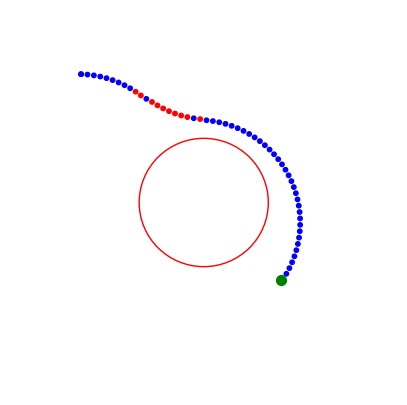

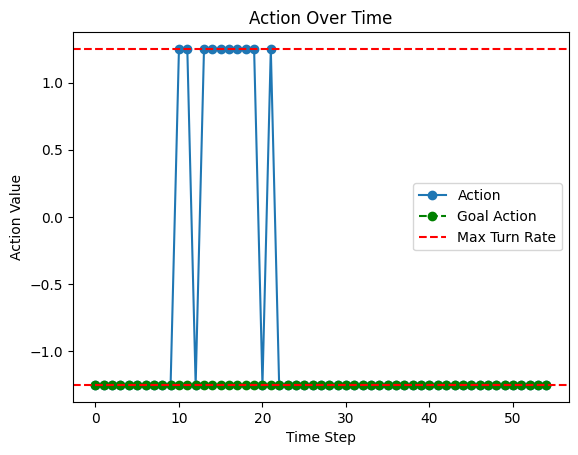

In [19]:
dubin_env = DubinEnv(start_state=np.array([-1.0, 1.0, 0.0]),
                     goal_state=0.6*np.array([1, -1, 0.0]))

brt = LatentDubinContinuousAction()

priv_states = []
actions = []
goal_actions = []
current_safe = []

epsilon = 0.25
simlen = 1000

# first step
demo, priv_state = dubin_env.forward(0)
safe_value, safe_action = brt.obs_to_brt(demo)

for i in range(simlen):
    # get goal reference direction and action
    goal_dir, goal_act = dubin_env.goal_ref()    
    curr_safe = 1 

    if safe_value < epsilon: 
        action = safe_action[0]
        curr_safe = 0 # when safe action is engaged
        print('Safe action engaged!')
    else:
        action = goal_act # nominal action otherwise
    
    priv_states.append(priv_state)
    actions.append(action)
    goal_actions.append(goal_act)
    current_safe.append(curr_safe)
    
    demo, priv_state = dubin_env.forward(action)
    safe_value, safe_action = brt.obs_to_brt(demo) # actual safe value after taking the action
    dubin_env.curr_state = priv_state  # Update the current state in the environment
    
    distance = np.linalg.norm(dubin_env.goal_state[:2] - dubin_env.curr_state[:2])
    print(f"Step {i+1}: Pstate: {np.round(priv_state,2)}, "
          f"Goal: {np.round(goal_dir,2)}, "
          f"Action: {np.around(action,2)}, "
          f"Dist: {np.round(distance,2)}, "
          f"Safe Value: {np.round(safe_value, 3)}")
    
    if distance < 0.05:
        print("Reached the goal!")
        break


# plot the trajectory history and circle obstacle 
fig,ax = plt.subplots()
# hardcoded with existing limits
sf = 1 # scale factor
plt.xlim([sf*brt.args.x_min, sf*brt.args.x_max])
plt.ylim([sf*brt.args.y_min, sf*brt.args.y_max])
plt.axis('off')
fig.set_size_inches(5, 5)
pss = np.array(priv_states)
circle = patches.Circle((0,0), 0.5, edgecolor=(1,0,0), facecolor='none')
ax.add_patch(circle)
col = np.where(np.array(current_safe) == 1, 'blue', 'red')
plt.scatter(pss[:,0], pss[:,1], c=col, s=10, label='Trajectory')
plt.scatter(dubin_env.goal_state[0], dubin_env.goal_state[1], c='green', s=50, label='Goal')

# plot action over time
plt.figure()
plt.plot(np.array(actions), label='Action', marker='o')
plt.plot(np.array(goal_actions), label='Goal Action', marker='o', linestyle='--', color='green')
plt.axhline(y=dubin_env.args.turnRate, color='r', linestyle='--', label='Max Turn Rate')
plt.axhline(y=-dubin_env.args.turnRate, color='r', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Action Value')
plt.title('Action Over Time')
plt.legend()
plt.show()
    


